# Imports

In [ ]:
import os
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import drive

# Mount Google Drive

In [ ]:
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/GPpics'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load and preprocess data

In [ ]:
def load_data(folder_path, variable_name="probabilityLiquidPrecipitation", target_size=(64, 64)):
    files = sorted(glob.glob(os.path.join(folder_path, "*.nc4")))
    data = []
    for file in files:
        try:
            with h5py.File(file, "r") as f:
                arr = f[variable_name][:]
                if arr.ndim == 3:
                    for i in range(arr.shape[0]):
                        img = resize(arr[i], target_size, anti_aliasing=True)
                        data.append(img)
        except Exception as e:
            print(f"Skipping {file} due to error: {e}")
    return np.array(data)

raw_data = load_data(DATA_DIR)
print("Loaded frames:", raw_data.shape)


Loaded frames: (228, 64, 64)


# Load and preprocess data

In [ ]:
def create_sequences(data, past_steps=6, future_steps=1):
    X, y = [], []
    for i in range(len(data) - past_steps - future_steps + 1):
        X.append(data[i:i+past_steps])
        y.append(data[i+past_steps:i+past_steps+future_steps][0])
    X = np.expand_dims(np.array(X), axis=-1)
    y = np.expand_dims(np.array(y), axis=-1)
    return X, y
X, y = create_sequences(raw_data)
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (222, 6, 64, 64, 1) y shape: (222, 64, 64, 1)


# Build model

In [ ]:
model = Sequential([
    ConvLSTM2D(64, (3, 3), padding='same', return_sequences=True, input_shape=X.shape[1:]),
    BatchNormalization(),
    ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 6, 64, 64, 64)  │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 64, 64, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 64, 64, 64)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 464,449 (1.77 MB)

 Trainable params: 464,193 (1.77 MB)

 Non-trainable params: 256 (1.00 KB)

# Train

In [ ]:
model.fit(X, y, epochs=10, batch_size=4, validation_split=0.1)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - loss: 0.0641 - val_loss: 5.6986e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - loss: 3.4088e-06 - val_loss: 7.7949e-06
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 2.3355e-06 - val_loss: 7.8013e-06
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 1.9962e-06 - val_loss: 7.8020e-06
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 1.7586e-06 - val_loss: 7.8020e-06
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 1.5916e-06 - val_loss: 7.8020e-06
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 1.4857e-06 - val_loss: 7.8020e-06
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 1.4401e-06 - val_loss: 7.8020e-06
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 1.3765e-06 - val_loss: 7.8020e-06
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 1.3553e-06 - val_loss: 7.7838e-06


# Evaluation

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 582ms/step
MAE: 0.0026, RMSE: 0.0028, R²: -8.7718
SSIM (avg over 10 samples): 0.9287
PSNR (avg over 10 samples): 51.13 dB


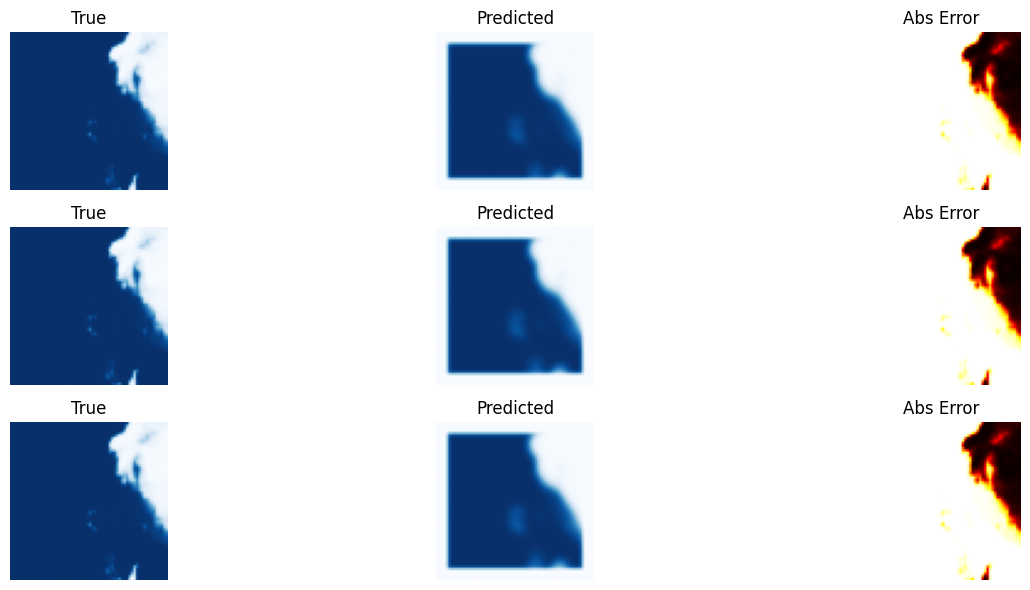

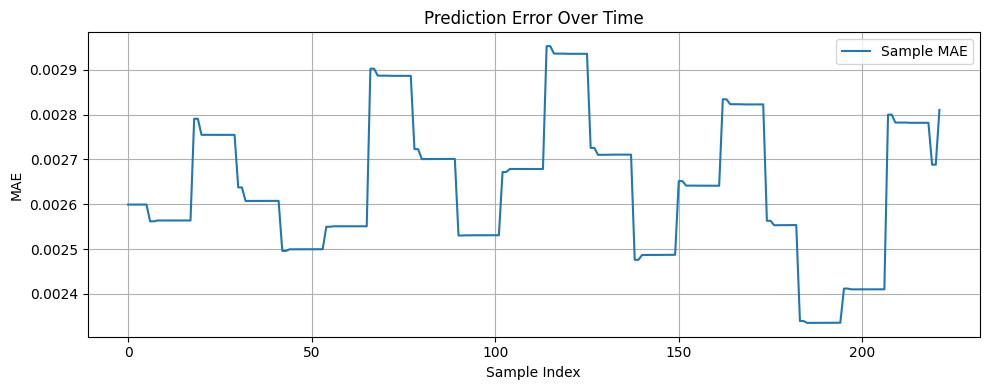

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

y_pred = model.predict(X)


y_true_flat = y.reshape(-1)
y_pred_flat = y_pred.reshape(-1)


mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2 = r2_score(y_true_flat, y_pred_flat)
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")


N = 10
ssim_scores = []
psnr_scores = []
for i in range(N):
    ssim_val = ssim(y[i].squeeze(), y_pred[i].squeeze(), data_range=1.0)
    psnr_val = psnr(y[i].squeeze(), y_pred[i].squeeze(), data_range=1.0)
    ssim_scores.append(ssim_val)
    psnr_scores.append(psnr_val)

print(f"SSIM (avg over {N} samples): {np.mean(ssim_scores):.4f}")
print(f"PSNR (avg over {N} samples): {np.mean(psnr_scores):.2f} dB")


plt.figure(figsize=(15, 6))
for i in range(3):
    plt.subplot(3, 3, i*3+1)
    plt.imshow(y[i].squeeze(), cmap='Blues')
    plt.title("True")
    plt.axis('off')

    plt.subplot(3, 3, i*3+2)
    plt.imshow(y_pred[i].squeeze(), cmap='Blues')
    plt.title("Predicted")
    plt.axis('off')

    plt.subplot(3, 3, i*3+3)
    diff = np.abs(y[i].squeeze() - y_pred[i].squeeze())
    plt.imshow(diff, cmap='hot')
    plt.title("Abs Error")
    plt.axis('off')

plt.tight_layout()
plt.show()


sample_maes = [mean_absolute_error(y[i].flatten(), y_pred[i].flatten()) for i in range(len(y))]
plt.figure(figsize=(10, 4))
plt.plot(sample_maes, label="Sample MAE")
plt.xlabel("Sample Index")
plt.ylabel("MAE")
plt.title("Prediction Error Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Save model

In [ ]:
model.save("/content/drive/MyDrive/ConvLSTM_Precipitation64x64.h5")